<h1 style="color: #C0392B;">
Les régions françaises les plus dynamiques : peut-on prédire la création d’entreprise ?</h1>



<span style="color: #2E86C1;"> *Par Tom Proust, Tristan Czarnecki et Thomas Favant*
</span>.

Comment a-t-on défini les créations d'entreprises? (Startup? PME? ???)

### Installation des bibliothèques

In [2]:
#mettre tous les imports nécessaires pour l'exécution de toutes les fonctions du dossiers 'mes_fonctions.py'
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import geopandas as gpd
from cartiflette import carti_download


### Plan

1.	Récupération de données
2.	Statistiques descriptives
3.	Modélisation

<h1 style="color: #C0392B;">
1. Récupération des données </h1>

Je pense qu'on pourrait décrire comment on a récupérer deux ou trois jeux de données et les difficultés rencontrées/ méthodes mises en place:
- API
- Merge de tableau
- utilisation des codes de région de l'INSEE
- Gros tri de gros dataset

(Je pourrais aussi parler des problématiques des données et de Github)

Après on dit qu'on ne va pas plus s'attarder sur l'obtention des autres variables explicatives et qu'elles sont disponibles dans le dossier 'Variables explicatives'.

Selon moi dans ce genre de projet, il faut montrer qu'on a eu une démarche réfléchie dans la récolte des données, qu'on a essayé des choses et qu'on a appris de nos erreurs. En faisant ça, on peut viser comme on a un sujet qui rentre bien dans le cadre de l'évaluation, on peut avoir une excellente note.

<h1 style="color: #C0392B;">
2. Statistiques descriptives </h1>

Avant de quantifier les relations par l'économétrie, l'analyse cartographique nous permet de mettre en évidence une géographie de l'inégalité entrepreneuriale. Nous chercherons notamment à voir si les zones de fort chômage coïncident spatialement avec les zones de faible création (test visuel de l'hypothèse 'Pull').

<>:14: SyntaxWarning: invalid escape sequence '\V'
<>:14: SyntaxWarning: invalid escape sequence '\V'
C:\Users\thoma\AppData\Local\Temp\ipykernel_33856\434834233.py:14: SyntaxWarning: invalid escape sequence '\V'
  chomage = pd.read_csv("data\Variables explicatives\chomage_format_long.csv")


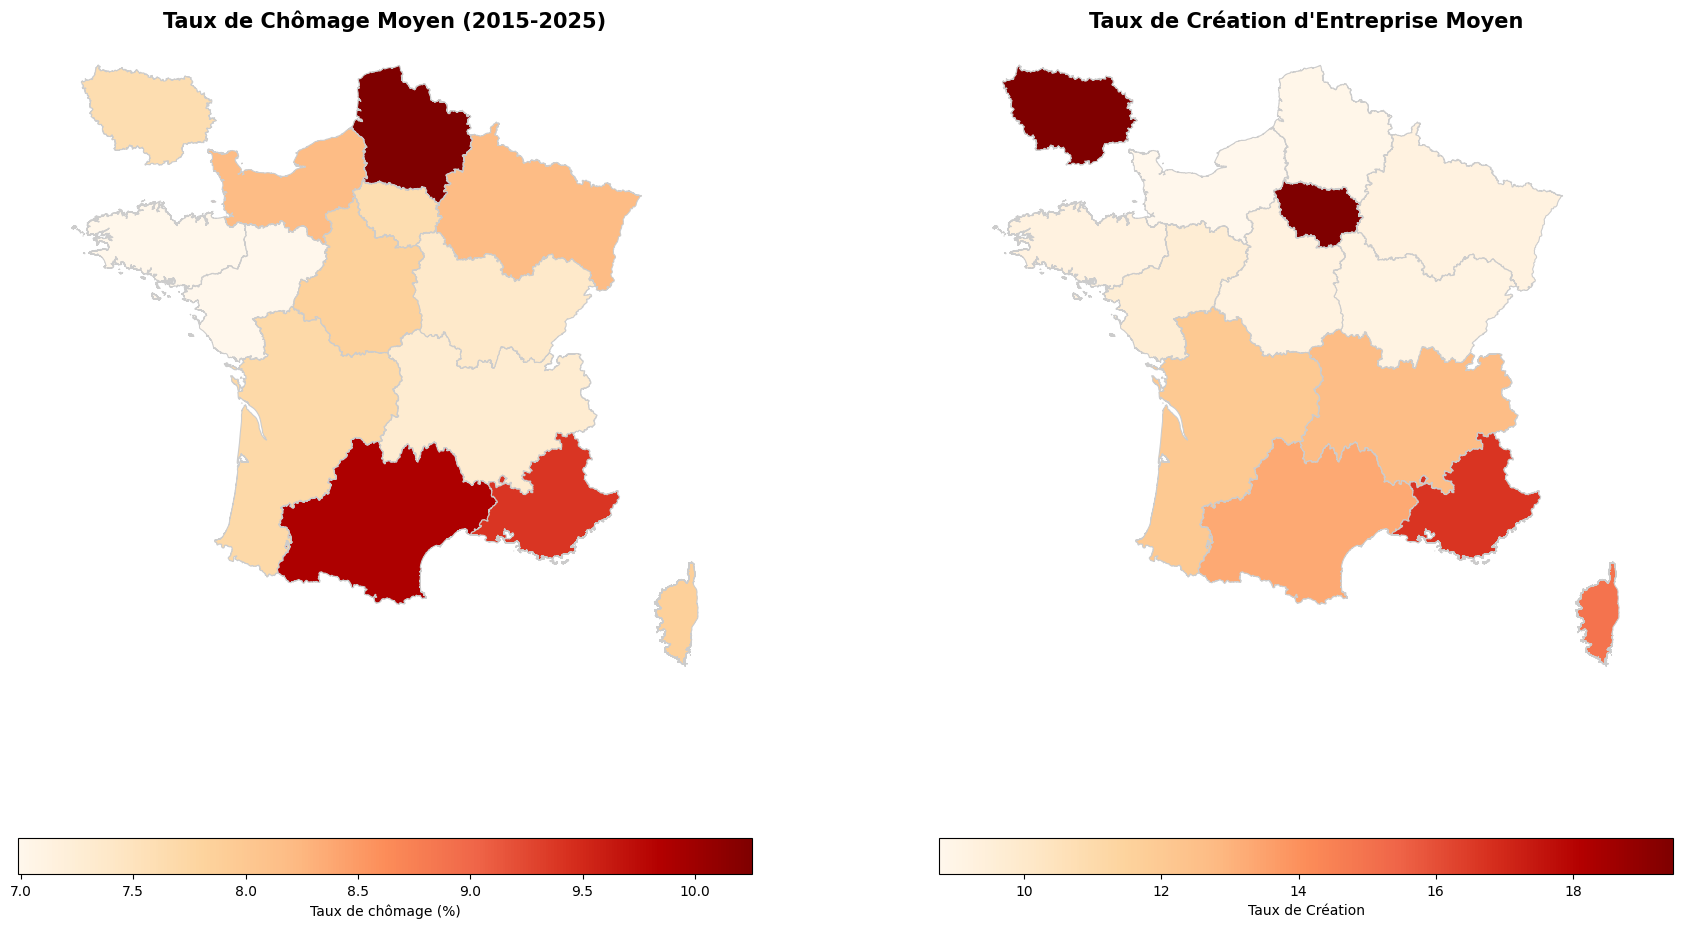

In [3]:
regions = carti_download(
    values="France",
    crs=4326,
    borders="REGION",
    vectorfile_format="geojson",
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)

regions = regions.rename(columns={'LIBELLE_REGION': 'region_nom'})

#récuperer la population par région de population_par_region_annee.csv
chomage = pd.read_csv("data\Variables explicatives\chomage_format_long.csv")
creation_moyenne = pd.read_csv(r"data\Variables explicatives\avg_creation_2015_2025.csv")

#Faire la moyenne du taux de chomage par région sur les années disponibles
chomage_moyenne = chomage.groupby('Region')['Taux de chômage par région'].mean().reset_index()
chomage_moyenne = chomage_moyenne.rename(columns={'Region': 'region_nom'})
creation_moyenne = creation_moyenne.rename(columns={'Region': 'region_nom'})

gdf_final_chomage = regions.merge(chomage_moyenne, on='region_nom', how='left')
gdf_final_creation = regions.merge(creation_moyenne, on='region_nom', how='left')

# 1. CRÉATION DE L'ESPACE (1 ligne, 2 colonnes)
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# --- CARTE 1 : CHÔMAGE (À GAUCHE -> axes[0]) ---
gdf_final_chomage.plot(
    column='Taux de chômage par région',
    cmap='OrRd',          # Rouge/Orange pour le chômage
    linewidth=0.8,
    edgecolor='0.8',
    legend=True,
    # 'shrink': 0.7 permet de réduire la taille de la barre de légende pour qu'elle ne dépasse pas
    legend_kwds={'label': "Taux de chômage (%)", 'orientation': "horizontal", 'shrink': 0.7},
    ax=axes[0]            # C'est ici qu'on dit "mets-toi à gauche"
)
axes[0].set_title('Taux de Chômage Moyen (2015-2025)', fontsize=15, fontweight='bold')
axes[0].set_axis_off()


# --- CARTE 2 : CRÉATION (À DROITE -> axes[1]) ---
# Vérifie bien le nom de ta colonne pour la création (ex: 'creations_per_1000' ou autre)
gdf_final_creation.plot(
    column='Création moyenne d\'entreprise par an entre 2015 et 2025 par 1000 habitants',
    cmap='OrRd',        # Vert pour la création (contraste visuel)
    linewidth=0.8,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Taux de Création", 'orientation': "horizontal", 'shrink': 0.7},
    ax=axes[1]            # C'est ici qu'on dit "mets-toi à droite"
)
axes[1].set_title("Taux de Création d'Entreprise Moyen", fontsize=15, fontweight='bold')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

### 1. Analyse de l'Hétérogénéité Spatiale : Une France à deux vitesses

L'observation de la carte du Taux de Création d'Entreprise Moyen (à droite) révèle de fortes disparités territoriales qui peuvent s'interpréter à travers plusieurs concepts de sociologie urbaine et de géographie économique.

**Le phénomène de Métropolisation et l'effet "Capitale"** : La carte met en évidence la position hégémonique de l'Île-de-France (en rouge foncé). Avec un taux de création supérieur à 16-18%, la région capitale illustre la concentration des capitaux, des talents (les "classes créatives" définies par Richard Florida) et des infrastructures. C'est l'illustration parfaite des économies d'agglomération : la densité d'acteurs économiques favorise l'innovation et la création de nouvelles structures.

**L'attrait du "Sunbelt" à la française (Héliotropisme)** : On observe une dynamique claire en faveur de la façade Atlantique et du Sud (Nouvelle-Aquitaine, Auvergne-Rhône-Alpes, PACA, Occitanie), représentées en orange soutenu. Cela correspond à un déplacement du centre de gravité économique vers les régions offrant un cadre de vie attractif, attirant une population souvent qualifiée ou désireuse de créer sa propre activité (néo-ruraux, entrepreneurs mobiles).

**La fracture territoriale (Centre-Périphérie)** : À l'opposé, les régions du Nord-Est (Grand-Est, Bourgogne-Franche-Comté) et du Centre-Val de Loire apparaissent en retrait (teintes claires). Cela reflète la persistance de la "Diagonale des faibles densités" ou des anciens bassins industriels en reconversion, où la culture entrepreneuriale peut être moins marquée et le tissu économique moins propice à l'émergence spontanée de startups ("écosystèmes moins matures").

### 2. Corrélation Visuelle : Chômage vs Création (Le test du "Négatif Photo")

La juxtaposition des deux cartes permet de tester visuellement l'hypothèse économique de l'effet "Pull" (l'économie saine attire la création).

Confirmation de la corrélation inverse dans le Nord : La région Hauts-de-France est le cas d'école qui valide notre modèle.

Carte de Gauche (Chômage) : Rouge foncé (Taux très élevé, > 9.5%).

Carte de Droite (Création) : Beige très clair (Taux très faible, < 12%).

**Conclusion** : Ici, la précarité économique agit clairement comme un frein. Le chômage élevé ne "pousse" pas à la création, il l'inhibe, confirmant l'absence d'entrepreneuriat de nécessité massif.

Le Paradoxe du Sud (La nuance nécessaire) : L'analyse visuelle permet de nuancer le modèle statistique global. Regardons l'Occitanie et la région PACA :

Elles ont des taux de chômage élevés (Rouge foncé à gauche).

Pourtant, elles ont aussi des taux de création élevés (Orange/Rouge à droite).

**Interprétation** : Cela suggère qu'un autre facteur compense l'effet négatif du chômage dans ces régions. Notre modèle de régression nous a donné la réponse : la Variation de la Population (coefficient +2.72). Le dynamisme démographique de ces régions (flux migratoires positifs) soutient la création d'entreprise malgré un chômage structurel élevé.

**Synthèse visuelle** : Globalement, on n'observe pas de superposition parfaite (les zones rouges de gauche ne sont pas les zones rouges de droite), ce qui confirme visuellement que le chômage n'est pas un moteur de création. Cependant, la relation n'est pas parfaitement linéaire partout : l'attractivité résidentielle (Sud) peut "casser" cette corrélation négative.

Il semble y avoir une corrélation négative entre chômage et création d'entreprise, qu'on va analyser.

Le but est d'analyser la corrélation entre le taux de chômage et la création d'entreprises par 1000 habitants dans différentes régions et périodes.Pour cela, on écrit une fonction dans 'analyse_correlation_chomage_creation.py' qui calcule le coefficient de corrélation de Pearson entre le taux de chômage et la création d'entreprises par 1000 habitants.

In [7]:
import pandas as pd
correlation_chomage_creation=pd.read_csv("data\Variables explicatives\correlation_chomage_creation.csv")

# Là, tu importes ta fonction depuis ton fichier
from mes_fonctions import analyser_relation_chomage_creation

# Et tu l'utilises
analyser_relation_chomage_creation(correlation_chomage_creation)



<>:2: SyntaxWarning: invalid escape sequence '\V'
<>:2: SyntaxWarning: invalid escape sequence '\V'
C:\Users\thoma\AppData\Local\Temp\ipykernel_33856\352451589.py:2: SyntaxWarning: invalid escape sequence '\V'
  correlation_chomage_creation=pd.read_csv("data\Variables explicatives\correlation_chomage_creation.csv")


ModuleNotFoundError: No module named 'mes_fonctions'

Analyse de la corrélation : confirmation statistique et nuances
Le nuage de points ci-contre permet d'objectiver et de quantifier la relation inverse pressentie lors de l'observation des cartes. L'analyse de cette distribution révèle trois enseignements majeurs :

1. Une corrélation négative confirmant la nature "pro-cyclique" Avec un coefficient de corrélation de -0.35, la relation est inverse et modérément significative. La pente descendante de la droite de régression indique clairement que la bonne santé économique (faible chômage) est davantage corrélée à la création d'entreprises que la précarité.

Hypothèse "Push" (Nécessité) écartée : Si le chômage était le moteur principal (création par "dépit" ou survie), la pente serait positive.

Hypothèse "Pull" (Opportunité) validée : Les données corroborent une dynamique d'opportunité. Un marché de l'emploi sain (signe de dynamisme économique, confiance des ménages, accès au crédit facilité) constitue un terreau plus fertile pour l'entrepreneuriat.

2. Le chômage comme facteur limitant ("Plafond de verre"). L'analyse visuelle de la distribution met en évidence une contrainte forte : au-delà de 10 % de chômage, le taux de création ne décolle jamais (aucun point supérieur à 15 créations pour 1000 habitants). Un contexte économique dégradé semble donc agir comme un frein structurel, "interdisant" les dynamiques entrepreneuriales fortes.

3. La condition nécessaire, mais non suffisante La partie gauche du graphique (chômage faible, entre 6 et 8 %) montre une très forte disparité. Si c'est dans cette zone que l'on trouve les records de création (> 20), on y trouve aussi des taux beaucoup plus modestes. Conclusion : Un faible chômage est une condition nécessaire pour permettre une forte création d'entreprises, mais elle n'est pas suffisante. D'autres déterminants locaux (attractivité touristique, métropolisation, politiques locales) interviennent pour transformer ce potentiel économique en création effective.

<h1 style="color: #C0392B;">
3. Modélisation </h1>

<h1 style="color: #C0392B;">
3.1. Régression linéaire 1 </h1>

Afin d'identifier les facteurs influençant le dynamisme entrepreneurial des régions, nous procédons à une régression linéaire multiple (Méthode des Moindres Carrés Ordinaires - OLS).Le modèle économétrique testé est le suivant :$$TauxCréation_i = \beta_0 + \beta_1 \cdot Diplôme + \beta_2 \cdot Chômage + \beta_3 \cdot VariationPop + \beta_4 \cdot Densité + \epsilon_i$$

Choix des variables :Variable expliquée ($Y$) : Le taux de création d'entreprises (pour 1000 habitants), indicateur direct du dynamisme entrepreneurial.

**Variables explicatives ($X$)** :
- **Capital Humain** : Le pourcentage de diplômés du supérieur (proxy du niveau de qualification de la région).
- **Conjoncture Économique** : Le taux de chômage (pour tester l'effet "push" vs "pull").
- **Dynamisme Démographique** : La variation de la population (attractivité du territoire)
- **Agglomération** : La densité de population (effets de métropolisation).

Hypothèse de modélisation : Nous utilisons une approche "Pooled OLS" sur l'ensemble de notre panel (130 observations : 13 régions $\times$ 10 années). Cette méthode permet d'inclure des variables structurelles invariantes sur la période étudiée (comme le niveau de diplôme, fixé ici à son niveau de 2022) et de mesurer leur impact global sur les disparités inter-régionales.

Pour créer le dataset contenant la variable explicative et les variables explicatives, nous l'avons fait dans le notebook "regression.ipynb" pour vérifier que les merges des datasets de nos variables explicatives s'effectuaient correctement'. Le dataset s'appelle 'regression1'.

Les données sur les diplômes des français n'étaient disponibles qu'en 2022 sur l'INSEE donc nous avons fait une **hypothèse de stabilité** :
Le niveau d'éducation d'une région change très lentement. On peut raisonnablement supposer que si une région est très diplômée en 2022, elle l'était aussi (relativement aux autres) en 2015.

In [5]:
regression1 = pd.read_csv("data/Variables explicatives/regression1.csv")

# 1. Définition des variables
y = regression1['creations_per_1000']

# X = Les variables explicatives
features = [
    'Taux de chômage par région', 
    'Pourcentage_diplomes_superieur',     
    'variation_population_pourcentage', 
    'densité de population'
]
X = regression1[features]

# 2. Ajout de la constante (Intercept)
X = sm.add_constant(X)

# 3. Création et ajustement du modèle (MCO = Moindres Carrés Ordinaires)
model = sm.OLS(y, X)
results = model.fit()

# 4. Affichage du rapport complet
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:     creations_per_1000   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     42.58
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.70e-22
Time:                        15:00:57   Log-Likelihood:                -316.14
No. Observations:                 130   AIC:                             642.3
Df Residuals:                     125   BIC:                             656.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

### 1. Performance globale du modèle.

**Qualité de l'ajustement ($R^2$)** : 
Le $R^2$ est de 0.577. Cela signifie que notre modèle explique 57,7 % de la variance du taux de création d'entreprises. 
Pour des données socio-économiques, c'est un score élevé, indiquant que les variables choisies sont très pertinentes pour expliquer le phénomène.Significativité globale (F-statistic) : La probabilité associée (Prob F-statistic: $1.70e-22$) est quasi nulle, ce qui confirme que le modèle dans son ensemble est statistiquement valide.

### 2. Analyse des déterminants (Variables significatives).
Trois variables ont un impact statistiquement significatif (P-value < 0.05) sur la création d'entreprise :
- **Le Taux de Chômage** (Coef: -0.82, P<0.001) :Impact : Il existe une relation négative forte. Toutes choses égales par ailleurs, une augmentation de 1 point du taux de chômage entraîne une baisse de 0.82 point du taux de création.Interprétation : Ce résultat valide l'effet "Pull" (opportunité). La création d'entreprise est favorisée par une bonne santé économique. L'hypothèse de l'entrepreneuriat de nécessité (effet "Push"), où le chômage pousserait à la création, est ici rejetée.
- **Le Capital Humain / Diplômes** (Coef: +0.53, P<0.001) :Impact : Relation positive. Une augmentation de 1 point du pourcentage de diplômés du supérieur augmente le taux de création de 0.53 point.Interprétation : Le niveau de qualification d'un territoire est un moteur essentiel de l'entrepreneuriat.
- **Le Dynamisme Démographique** (Coef: +2.72, P=0.003) :Impact : Relation positive très forte. Une région dont la population croît attire les créateurs. C'est un indicateur d'attractivité du territoire (demande locale croissante).

### 3. La variable non-significative.
La Densité de population (P=0.540) :Avec une P-value de 0.54 (bien supérieure au seuil de 0.05), nous ne pouvons pas conclure que la densité de population a un impact direct sur la création d'entreprises, une fois que l'on contrôle déjà pour le niveau d'éducation et le chômage. L'effet "métropole" passe probablement déjà par la variable des diplômés.

Note Méthodologique (Limites)Le test de Durbin-Watson est de 0.410, ce qui est faible (loin de la valeur cible de 2). Cela indique une présence d'autocorrélation positive dans les résidus. C'est attendu dans ce type de modèle "Pooled OLS" où les mêmes régions sont suivies sur plusieurs années. Bien que cela n'invalide pas les coefficients (la tendance reste vraie), cela suggère que la précision des intervalles de confiance pourrait être surestimée.

In [6]:
salaires=pd.read_csv("data/Variables explicatives/salaires_EQTP.csv")